Импорт необходимых модулей:

In [1]:
import imp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import numpy as np
from PIL import Image 

from cmath import isclose
import math

import multiprocessing
from joblib import Parallel, delayed
# from math import isqrt

import platform
import subprocess
import shutil

C:\Users\Joel\AppData\Local\Temp\ipykernel_19848\4022817702.py:1: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


### Генерируем точки + строим графики и изображения

In [2]:
#sample_size_sqrt = 3163
sample_size_sqrt = 3163
sample_size = sample_size_sqrt * sample_size_sqrt

isClassic = False

classic = ''
if isClassic:
    classic = ' --classic'

print(sample_size)

10004569


Build через CMake & Запуск генерации точек

In [3]:
if ( os.path.exists('bin/') ):
    shutil.rmtree('bin/')

In [4]:
if platform.system() == 'Windows':
    subprocess.run(['cmake', '..', '-B..\\bin\\', '-DCMAKE_BUILD_TYPE=Release', '-DCMAKE_TOOLCHAIN_FILE=C:\\vcpkg\\scripts\\buildsystems\\vcpkg.cmake', '-GNinja'])
    subprocess.run(['cmake', '--build', '..\\bin\\', '--config=release'])

    out = subprocess.check_output( "..\\bin\\generator_research.exe -g xor-shift-64 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "..\\bin\\generator_research.exe -g xor-shift-1024 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "..\\bin\\generator_research.exe -g mt19937 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "..\\bin\\generator_research.exe -g rand16 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "..\\bin\\generator_research.exe -g rand32 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)
else:
    subprocess.run(['cmake', '.', '-B../bin/', '-DCMAKE_BUILD_TYPE=Release', '-GNinja'])
    subprocess.run(['cmake', '--build', '../bin/', '--config=release'])

    out = subprocess.check_output( "./bin/generator_research -g xor-shift-64 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/generator_research -g xor-shift-1024 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/generator_research -g mt19937 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/generator_research -g rand16 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/generator_research -g rand32 -s " + str(sample_size) + str(classic), shell=True, text=True )
    print(out)

Elapsed time for generator: "xs64"; Total values: 10004569	 --- 51191654 microseconds

Elapsed time for generator: "xs1024"; Total values: 10004569	 --- 50933540 microseconds

Elapsed time for generator: "mt19937"; Total values: 10004569	 --- 51496072 microseconds

Elapsed time for generator: "rand16"; Total values: 10004569	 --- 51486546 microseconds

Elapsed time for generator: "rand32"; Total values: 10004569	 --- 50770287 microseconds



Подгружаем сгенерированные выборки:

In [5]:
x64      = pd.read_csv("xs64.csv")
x1024    = pd.read_csv("xs1024.csv")
mt19937  = pd.read_csv("mt19937.csv")
rand16     = pd.read_csv("rand16.csv")
rand32     = pd.read_csv("rand32.csv")

Вывод первых 5-ти значий со сгенерированного файла:

In [6]:
x64.head()

,randoms
0,0.194804
1,0.887926
2,0.984871
3,0.408211
4,0.286288


Описательная статистика:

In [7]:
x64['randoms'].describe()

count    1.000457e+07
mean     4.999872e-01
std      2.886470e-01
min      1.297450e-08
25%      2.501730e-01
50%      4.999610e-01
75%      7.500710e-01
max      1.000000e+00
Name: randoms, dtype: float64

Строим гистограммы:

In [8]:
bins = 1000
bins_ranges = np.arange(start=0, stop=1, step=1 / bins)

In [9]:
hist_x64, bins_ranges = np.histogram(x64.to_numpy(), bins_ranges)
hist_x1024, bins_ranges = np.histogram(x1024.to_numpy(), bins_ranges)
hist_mt19937, bins_ranges = np.histogram(mt19937.to_numpy(), bins_ranges)
hist_rand16, bins_ranges = np.histogram(rand16.to_numpy(), bins_ranges)
hist_rand32, bins_ranges = np.histogram(rand32.to_numpy(), bins_ranges)

(9725.0, 10318.0)

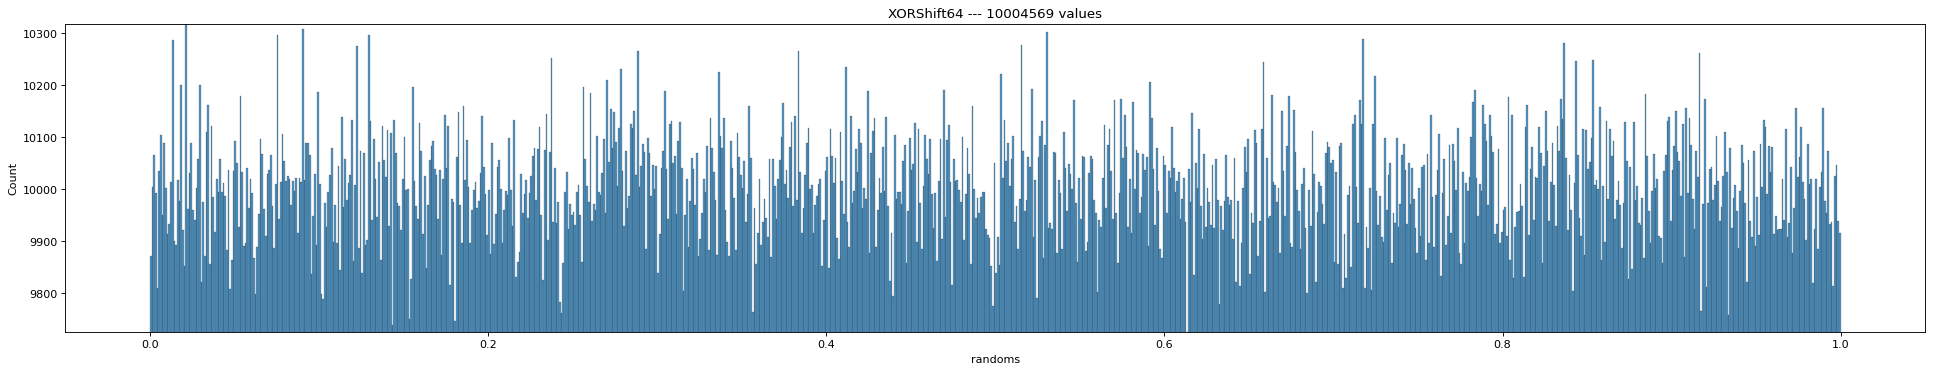

In [10]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x64, x="randoms", bins=bins).set(title='XORShift64 --- ' + str(sample_size) + ' values')

plt.ylim(bottom=np.min(hist_x64), top=np.max(hist_x64))

In [11]:
data = 255 * np.array(x64)
data = np.uint8(data)

In [12]:
data.shape

(10004569, 1)

In [13]:
data = data.reshape(sample_size_sqrt, sample_size_sqrt)
print(data)

[[ 49 226 251 ... 152 230  98]
 [137 241   5 ...   9 178  42]
 [103  89 154 ... 159  65  51]
 ...
 [159   3 246 ...  84  93 225]
 [ 13 174  91 ...  19  14 222]
 [164  71 169 ...  42 132 182]]


In [14]:
data.shape

(3163, 3163)

In [15]:
img = Image.fromarray(data, 'L')
img.save('XORShift64_' + str(sample_size) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9698.0, 10320.0)

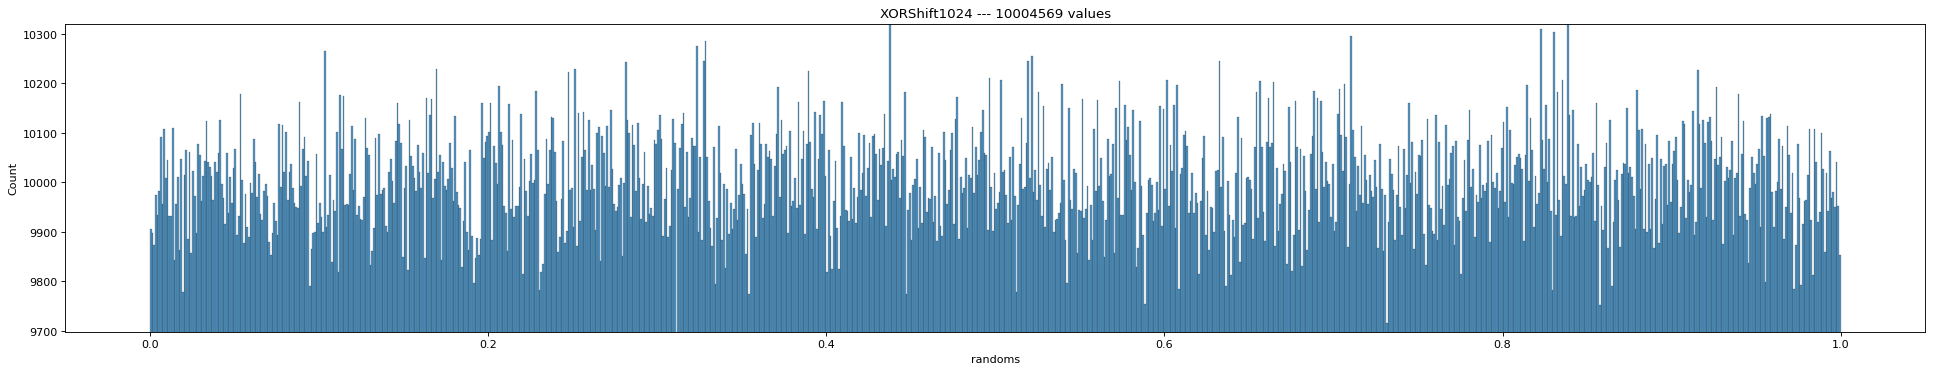

In [16]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x1024, x="randoms", bins=bins).set(title='XORShift1024 --- ' + str(sample_size) + ' values')

plt.ylim(bottom=np.min(hist_x1024), top=np.max(hist_x1024))

In [17]:
data = 255 * np.array(x1024)
data = np.uint8(data)
data = data.reshape(sample_size_sqrt, sample_size_sqrt)

In [18]:
img = Image.fromarray(data, 'L')
img.save('XORShift1024_' + str(sample_size) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9656.0, 10347.0)

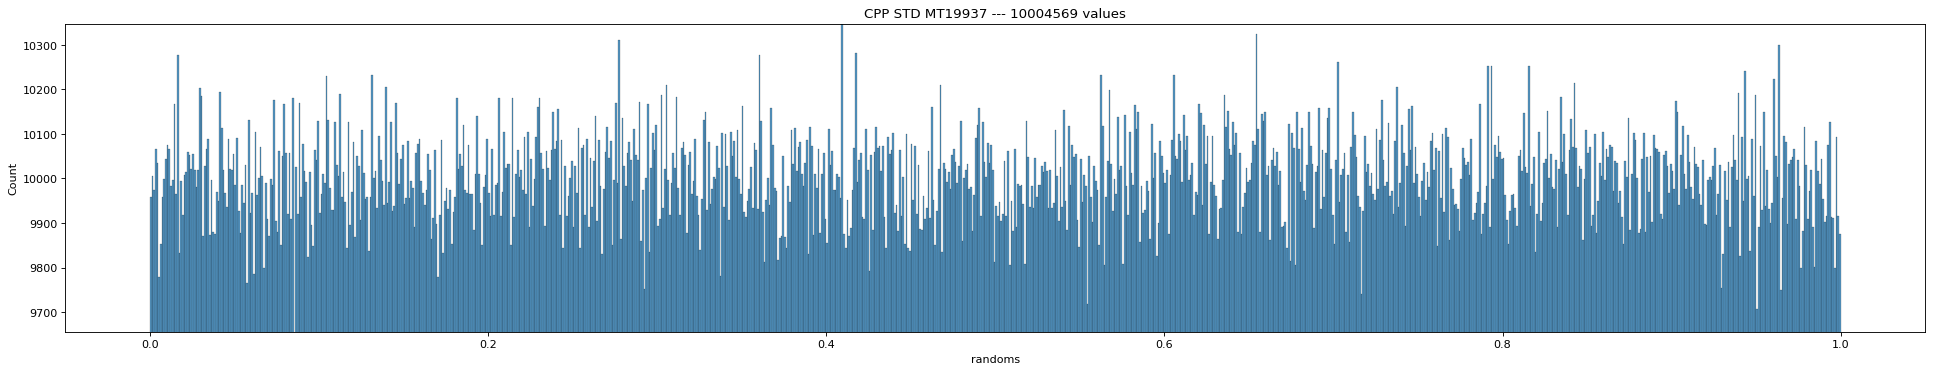

In [19]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=mt19937, x="randoms", bins=bins).set(title='CPP STD MT19937 --- ' + str(sample_size) + ' values')

plt.ylim(bottom=np.min(hist_mt19937), top=np.max(hist_mt19937))

In [20]:
data = 255 * np.array(mt19937)
data = np.uint8(data)
data = data.reshape(sample_size_sqrt, sample_size_sqrt)

In [21]:
img = Image.fromarray(data, 'L')
img.save('MT19937_' + str(sample_size) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(0.0, 1000457.0)

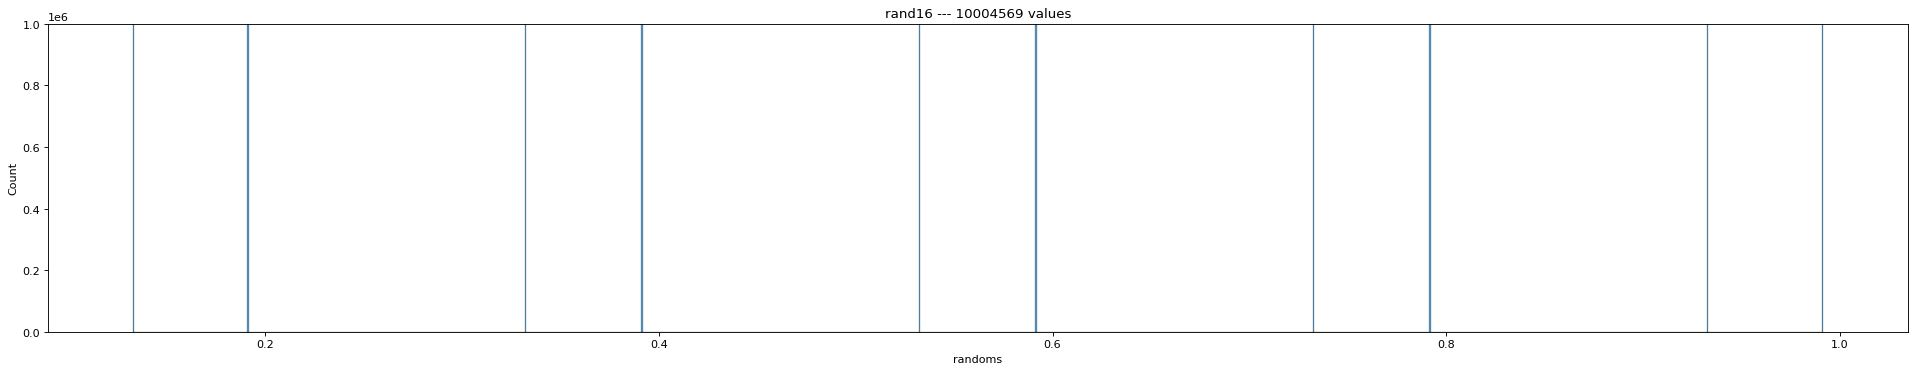

In [22]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=rand16, x="randoms", bins=bins).set(title='rand16 --- ' + str(sample_size) + ' values')

plt.ylim(bottom=np.min(hist_rand16), top=np.max(hist_rand16))

In [23]:
data = 255 * np.array(rand16)
data = np.uint8(data)
data = data.reshape(sample_size_sqrt, sample_size_sqrt)

In [24]:
img = Image.fromarray(data, 'L')
img.save('rand16_' + str(sample_size) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(0.0, 20355.0)

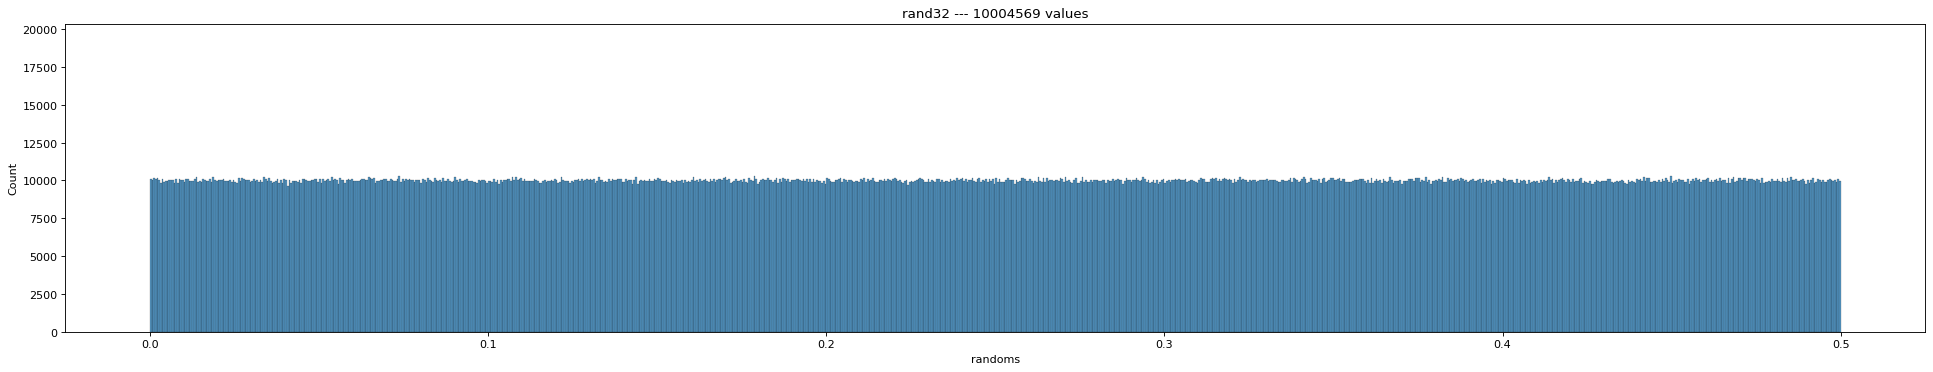

In [25]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=rand32, x="randoms", bins=bins).set(title='rand32 --- ' + str(sample_size) + ' values')

plt.ylim(bottom=np.min(hist_rand32), top=np.max(hist_rand32))

In [26]:
data = 255 * np.array(rand32)
data = np.uint8(data)
data = data.reshape(sample_size_sqrt, sample_size_sqrt)

In [27]:
img = Image.fromarray(data, 'L')
img.save('rand32_' + str(sample_size) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

## Метрики качества

In [28]:
# метод проверки, что хотя бы одно сгенерированное число из выборки есть в диапазоне [left..right), 
# ИДЕАЛЬНЫЙ ГЕНЕРАТОР выдаст ОДНО ЧИСЛО на ОДИН ДИАПАЗОН
def parallel_task(left, step, generated_values):
    right = left + step # next элемент (правый сосед, как граница диапазона) из массива expected_values

    for generated in generated_values:
        if (isclose(generated, left) or generated > left) and generated < right:
            # если сгенерированное число (generated) >= левой границе диапазона (left) и строго меньше правой границы (right) ---> выдать единицу
            return 1
                    
    return 0

# метод проверки качества сгенерированных значений, два типа проверки 'by-sum' -- быстрее и 'by-element' -- медленнее (но точнее)
def get_quality_of_values(generated_values, type='by-sum'):
    size = len(generated_values)

    # массив ожидаемых значений [0..1)
    range_step = 1.0 / size
    expected_values = np.arange(start=0, stop=1, step=range_step)    # ожидаемые значения ИДЕАЛЬНОГО ГЕНЕРАТОРА [0, 0.001, 0.002, ..., 1)

    generated_values = generated_values.to_numpy()
    error = None

    print(f'Expected values: {expected_values}')
    print(f'Generated values: {generated_values}')

    # проверка схожести суммы идеальных значений с суммой реальных значений
    # по сумме
    if type == 'by-sum':

        ideal_sum = expected_values.sum()
        real_sum = generated_values.sum()

        # отклонение от необходимой суммы в процентах
        error = abs( ideal_sum - real_sum ) 
        error /= ideal_sum

    # по элементно
    elif type == 'by-element':

        # parallel loop
        num_cores = multiprocessing.cpu_count()
        results = Parallel(n_jobs=num_cores)(delayed(parallel_task)(ideal, range_step, generated_values) for ideal in expected_values)

        # реальное количество диапазонов, в которых есть сгенерированные числа (В ИДЕАЛЕ, это число будет равно КОЛИЧЕСТВУ СГЕНЕРИРОВАННЫХ ЧИСЕЛ)
        good_elements = np.array(results).sum()

        error = 1 - good_elements / size
        print(f'Good elements: {good_elements}')
        print(f'Total generated values: {size}\nError: {error}')

    else:
        raise ValueError("Wrong type!")

    return 1 - error    # вывод качества с учётом ошибки ---> 1 - идеальный генератор, 0 - плохой генератор

Параметры для проверки качества:

In [29]:
#type = 'by-element'
type = 'by-sum'

Метрика качества для XorShift64:

In [30]:
quality = get_quality_of_values(x64, type)
print(f'XorShift64 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.194804]
 [0.887926]
 [0.984871]
 ...
 [0.167184]
 [0.519039]
 [0.716467]]
XorShift64 Quality: 0.9999745597863386


Метрика качества для XorShift1024:

In [31]:
quality = get_quality_of_values(x1024, type)
print(f'XorShift1024 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.675804  ]
 [0.903249  ]
 [0.626428  ]
 ...
 [0.431871  ]
 [0.678029  ]
 [0.00367072]]
XorShift1024 Quality: 0.9998103992866538


Метрика качества для MT19937:

In [32]:
quality = get_quality_of_values(mt19937, type)
print(f'MT19937 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.770683]
 [0.715568]
 [0.61605 ]
 ...
 [0.516298]
 [0.706314]
 [0.770517]]
MT19937 Quality: 0.9999041891891944


In [33]:
quality = get_quality_of_values(rand16, type)
print(f'rand16() Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.591629]
 [0.932577]
 [0.391645]
 ...
 [0.991629]
 [0.332592]
 [0.791629]]
rand16() Quality: 0.8757784017646799


In [34]:
quality = get_quality_of_values(rand32, type)
print(f'rand32() Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.435492]
 [0.355559]
 [0.272951]
 ...
 [0.458289]
 [0.305571]
 [0.354563]]
rand32() Quality: 0.4998798796497157


### Среднеквадратичное отклонение

In [35]:
size = len(hist_x64)
avg = np.mean(hist_x64)
max = np.max(hist_x64)
min = np.min(hist_x64)

# print(len(bins))
# print(avg)
# print(size)

RMSD = 0
for h in hist_x64:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for XorShift64 = {NRMSD}')

Root mean square deviation for XorShift64 = 0.16705660502261


In [36]:
size = len(hist_x1024)
avg = np.mean(hist_x1024)
max = np.max(hist_x1024)
min = np.min(hist_x1024)

RMSD = 0
for h in hist_x1024:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for XorShift1024 = {NRMSD}')

Root mean square deviation for XorShift1024 = 0.15700351107565425


In [37]:
size = len(hist_mt19937)
avg = np.mean(hist_mt19937)
max = np.max(hist_mt19937)
min = np.min(hist_mt19937)

RMSD = 0
for h in hist_mt19937:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for MT19937 = {NRMSD}')

Root mean square deviation for MT19937 = 0.14012029286434857


In [38]:
size = len(hist_rand16)
avg = np.mean(hist_rand16)
max = np.max(hist_rand16)
min = np.min(hist_rand16)

RMSD = 0
for h in hist_rand16:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for rand16() = {NRMSD}')

Root mean square deviation for rand16() = 0.09954801720051487


In [39]:
size = len(hist_rand32)
avg = np.mean(hist_rand32)
max = np.max(hist_rand32)
min = np.min(hist_rand32)

RMSD = 0
for h in hist_rand32:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for rand32() = {NRMSD}')

Root mean square deviation for rand32() = 0.4915270983783469
